# Sử dụng marked features chữ viết tay sang văn bản.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1) Cấu hình chung

Thiết lập tham số cho ảnh, tỉ lệ train/test và seed để tái lập kết quả.

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
IMG_SIZE = (32, 32)
LABELS = [str(i) for i in range(10)]

HOG_PARAMS = dict(
    winSize=IMG_SIZE,
    blockSize=(16, 16),
    blockStride=(8, 8),
    cellSize=(8, 8),
    nbins=9,
    derivAperture=1,
    winSigma=-1.0,
    histogramNormType=0,
    L2HysThreshold=0.2,
    gammaCorrection=True,
    nlevels=64,
    signedGradient=False,
)

In [3]:
def load_digits_dataset(img_size=IMG_SIZE):
    """Load sklearn digits và scale về ảnh uint8 kích thước đồng nhất."""
    digits = load_digits()
    images = digits.images
    labels = digits.target.astype(np.int32)

    resized_images = []
    for img in images:
        img_uint8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_resized = cv2.resize(img_uint8, img_size, interpolation=cv2.INTER_CUBIC)
        resized_images.append(img_resized)

    return np.array(resized_images), labels


def load_images_from_folder(root_dir, img_size=IMG_SIZE):
    """Đọc dữ liệu từ thư mục root/0..9/*.jpg|png|bmp."""
    valid_ext = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    X, y = [], []

    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path) or not class_name.isdigit():
            continue

        label = int(class_name)
        for fname in os.listdir(class_path):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in valid_ext:
                continue

            fpath = os.path.join(class_path, fname)
            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
            X.append(img)
            y.append(label)

    return np.array(X), np.array(y, dtype=np.int32)

## mô hình HOG + SVM

Class chịu trách nhiệm tiền xử lý ảnh, trích xuất HOG, huấn luyện, dự đoán và đánh giá.

In [4]:
class HOGSVMClassifier:
    def __init__(self, hog_params=None, C=10.0, kernel="rbf", gamma="scale"):
        self.hog_params = hog_params if hog_params is not None else HOG_PARAMS
        self.hog = cv2.HOGDescriptor(
            self.hog_params["winSize"],
            self.hog_params["blockSize"],
            self.hog_params["blockStride"],
            self.hog_params["cellSize"],
            self.hog_params["nbins"],
            self.hog_params["derivAperture"],
            self.hog_params["winSigma"],
            self.hog_params["histogramNormType"],
            self.hog_params["L2HysThreshold"],
            self.hog_params["gammaCorrection"],
            self.hog_params["nlevels"],
            self.hog_params["signedGradient"],
        )
        self.pipeline = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("svm", SVC(C=C, kernel=kernel, gamma=gamma)),
            ]
        )

    def preprocess(self, image):
        if image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image, self.hog_params["winSize"], interpolation=cv2.INTER_AREA)
        return image.astype(np.uint8)

    def extract_hog(self, image):
        proc = self.preprocess(image)
        feature = self.hog.compute(proc)
        return feature.flatten()

    def transform_batch(self, X):
        return np.array([self.extract_hog(img) for img in X])

    def fit(self, X_train, y_train):
        X_hog = self.transform_batch(X_train)
        self.pipeline.fit(X_hog, y_train)
        return self

    def predict(self, X):
        X_hog = self.transform_batch(X)
        return self.pipeline.predict(X_hog)

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, digits=4)
        cm = confusion_matrix(y_test, y_pred)
        return {"accuracy": acc, "report": report, "confusion_matrix": cm, "y_pred": y_pred}

In [5]:
class ModelVisualizer:
    @staticmethod
    def show_samples(X, y, n=12, cols=6, title="Mẫu dữ liệu"):
        n = min(n, len(X))
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(2.2 * cols, 2.2 * rows))
        for i in range(n):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(X[i], cmap="gray")
            plt.title(f"Label: {y[i]}")
            plt.axis("off")
        plt.suptitle(title, y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion(cm, labels=LABELS, title="Confusion Matrix"):
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def show_predictions(X, y_true, y_pred, n=20, cols=5):
        n = min(n, len(X))
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(2.6 * cols, 2.4 * rows))
        for i in range(n):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(X[i], cmap="gray")
            ok = y_true[i] == y_pred[i]
            color = "green" if ok else "red"
            plt.title(f"T: {y_true[i]} | P: {y_pred[i]}", color=color, fontsize=10)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

## train/test

Data source: sklearn.datasets.load_digits
X shape: (1797, 32, 32) | y shape: (1797,)
Train: (1437, 32, 32) (1437,)
Test : (360, 32, 32) (360,)


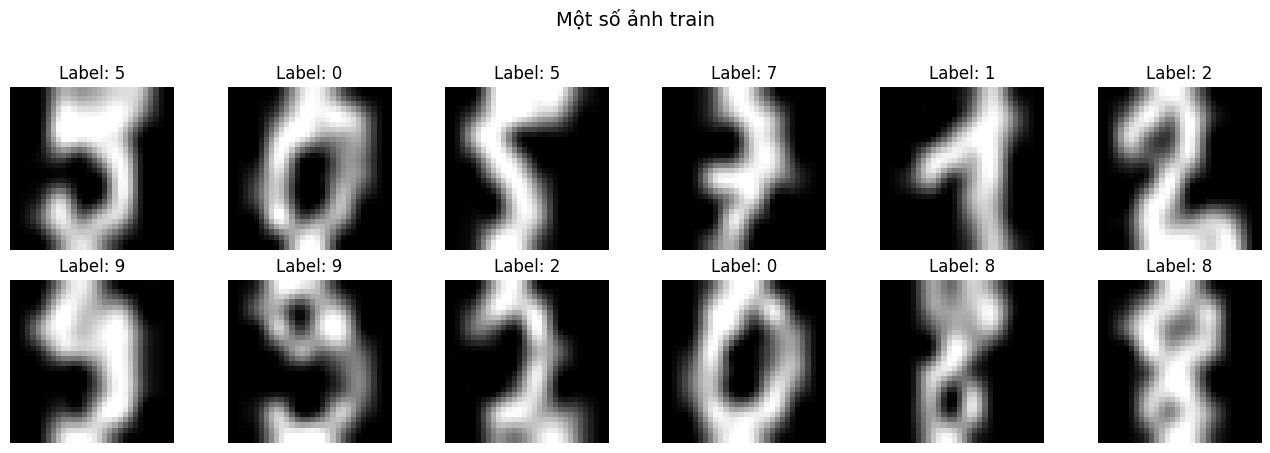

In [6]:
# Chọn 1 trong 2 cách nạp dữ liệu:
USE_CUSTOM_FOLDER = False
CUSTOM_DATASET_DIR = "./digits_dataset"  # Ví dụ: root/0..9/*.png

if USE_CUSTOM_FOLDER and os.path.isdir(CUSTOM_DATASET_DIR):
    X, y = load_images_from_folder(CUSTOM_DATASET_DIR, img_size=IMG_SIZE)
    data_source = f"Custom folder: {CUSTOM_DATASET_DIR}"
else:
    X, y = load_digits_dataset(img_size=IMG_SIZE)
    data_source = "sklearn.datasets.load_digits"

print("Data source:", data_source)
print("X shape:", X.shape, "| y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

ModelVisualizer.show_samples(X_train, y_train, n=12, cols=6, title="Một số ảnh train")

## Huấn luyện

In [7]:
model = HOGSVMClassifier(hog_params=HOG_PARAMS, C=10.0, kernel="rbf", gamma="scale")
model.fit(X_train, y_train)
print("Đã huấn luyện xong mô hình HOG + SVM.")

Đã huấn luyện xong mô hình HOG + SVM.


## Đánh giá mô hình

In accuracy, classification report và vẽ confusion matrix.

Accuracy: 0.9972

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     1.0000    1.0000    1.0000        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    1.0000    1.0000        36
           7     1.0000    1.0000    1.0000        36
           8     1.0000    1.0000    1.0000        35
           9     1.0000    0.9722    0.9859        36

    accuracy                         0.9972       360
   macro avg     0.9973    0.9972    0.9972       360
weighted avg     0.9973    0.9972    0.9972       360



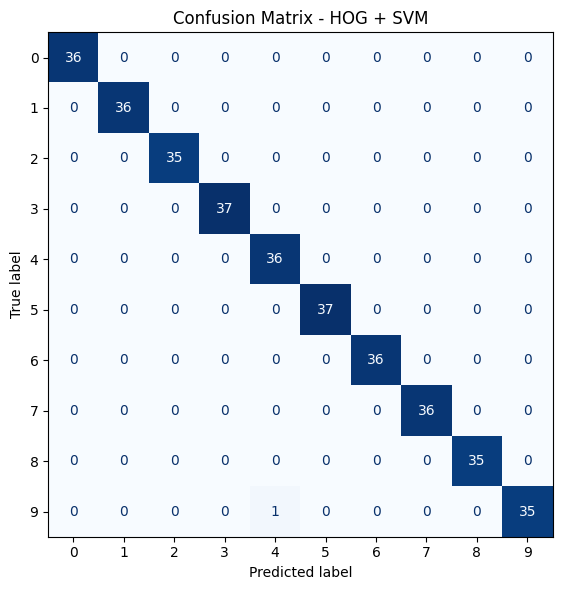

In [8]:
results = model.evaluate(X_test, y_test)
y_pred = results["y_pred"]

print(f"Accuracy: {results['accuracy']:.4f}")
print("\nClassification report:")
print(results["report"])

ModelVisualizer.plot_confusion(
    results["confusion_matrix"],
    labels=LABELS,
    title="Confusion Matrix - HOG + SVM",
)

## Trực quan kết quả dự đoán trên tập test

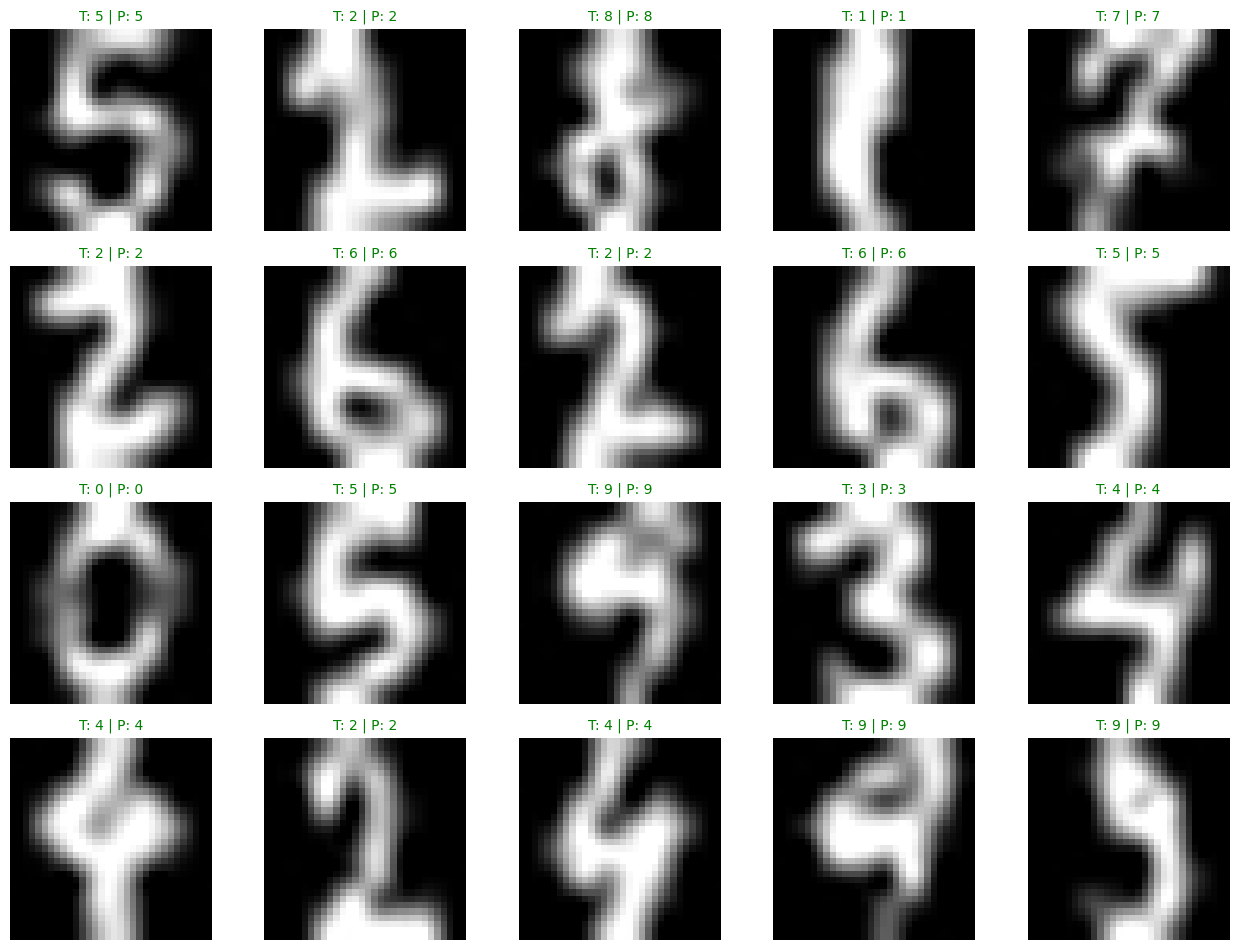

In [9]:
ModelVisualizer.show_predictions(X_test, y_test, y_pred, n=20, cols=5)

## Dự đoán ảnh đơn lẻ bên ngoài 

In [ ]:
def predict_single_image(model, image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

    pred = model.predict(np.array([img]))[0]

    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray")
    plt.title(f"Predicted: {pred}")
    plt.axis("off")
    plt.show()

    return pred

# Ví dụ dùng:
test_path = "./.png"
pred_label = predict_single_image(model, test_path)
print("Predicted label:", pred_label)